In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset


In [2]:
df = pd.read_csv(r"C:\Users\admin\Downloads\SkyCity Auckland Restaurants & Bars.csv")


# Basic Info

In [3]:
print(df.head())
print(df.info())
print(df.describe())


  CuisineType  RestaurantID          RestaurantName Segment       Subregion  \
0     Burgers         25731     Urban Burgers House    Cafe     North Shore   
1     Burgers         25123     Urban Burgers Diner     QSR  South Auckland   
2     Burgers         25177     King Burgers Eatery    Cafe   West Auckland   
3     Burgers         25540  Classic Burgers Tavern     QSR     North Shore   
4     Burgers         25258    Lucky Burgers Bistro    Cafe  South Auckland   

   GrowthFactor    AOV  MonthlyOrders  InStoreOrders  InStoreRevenue  ...  \
0          1.03  43.97            668            197         8662.09  ...   
1          1.05  40.45           1388            259        10476.55  ...   
2          1.04  40.03           1717            524        20975.72  ...   
3          1.03  36.28           1083            216         7836.48  ...   
4          1.05  34.34           1230            261         8962.74  ...   

   DeliveryCostPerOrder  SD_DeliveryTotalCost  InStoreNetProfi

# Missing Values

In [4]:
print(df.isnull().sum())

CuisineType              0
RestaurantID             0
RestaurantName           0
Segment                  0
Subregion                0
GrowthFactor             0
AOV                      0
MonthlyOrders            0
InStoreOrders            0
InStoreRevenue           0
UberEatsOrders           0
DoorDashOrders           0
SelfDeliveryOrders       0
UberEatsRevenue          0
DoorDashRevenue          0
SelfDeliveryRevenue      0
COGSRate                 0
OPEXRate                 0
CommissionRate           0
DeliveryRadiusKM         0
DeliveryCostPerOrder     0
SD_DeliveryTotalCost     0
InStoreNetProfit         0
UberEatsNetProfit        0
DoorDashNetProfit        0
SelfDeliveryNetProfit    0
InStoreShare             0
UE_share                 0
DD_share                 0
SD_share                 0
dtype: int64


# Total Net Profit

In [5]:
df['TotalNetProfit'] = (
    df['InStoreNetProfit'] +
    df['UberEatsNetProfit'] +
    df['DoorDashNetProfit'] +
    df['SelfDeliveryNetProfit']
)

# Profit per Order


In [6]:
df['ProfitPerOrder'] = df['TotalNetProfit'] / df['MonthlyOrders']

# Channel Revenue Ratios


In [7]:
df['UE_ratio'] = df['UberEatsRevenue'] / df['MonthlyOrders']
df['DD_ratio'] = df['DoorDashRevenue'] / df['MonthlyOrders']
df['SD_ratio'] = df['SelfDeliveryRevenue'] / df['MonthlyOrders']

# Interaction Features


In [8]:
df['Commission_Impact'] = df['CommissionRate'] * df['UE_share']
df['DeliveryCost_Impact'] = df['DeliveryCostPerOrder'] * df['SD_share']

# Correlation Heatmap


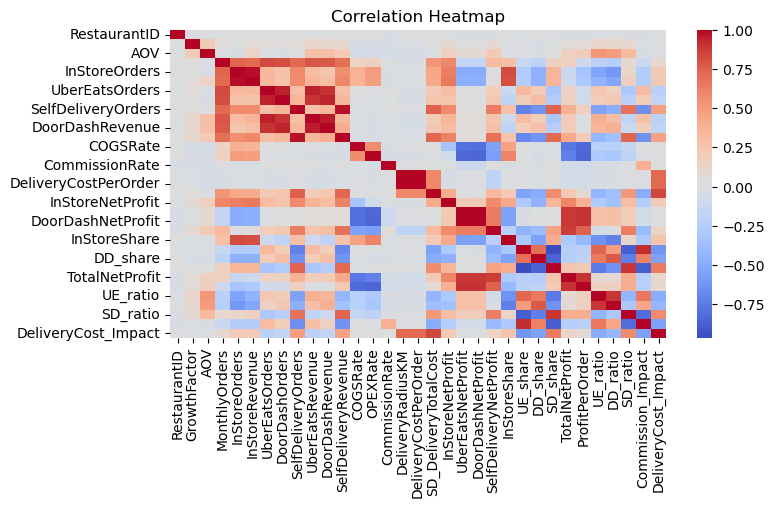

In [9]:
# Correlation Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Distribution Plots


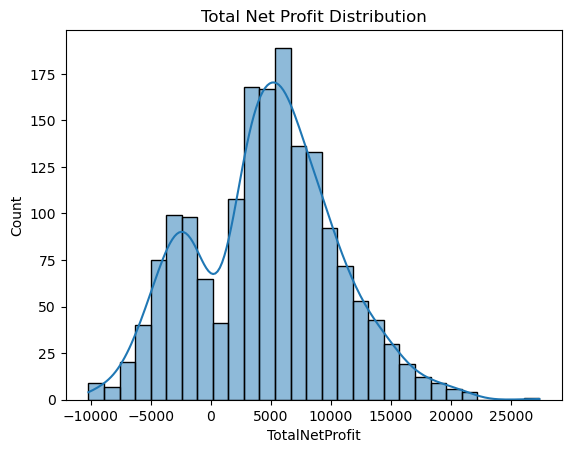

In [10]:
sns.histplot(df['TotalNetProfit'], kde=True)
plt.title("Total Net Profit Distribution")
plt.show()

# Channel Share vs Profit


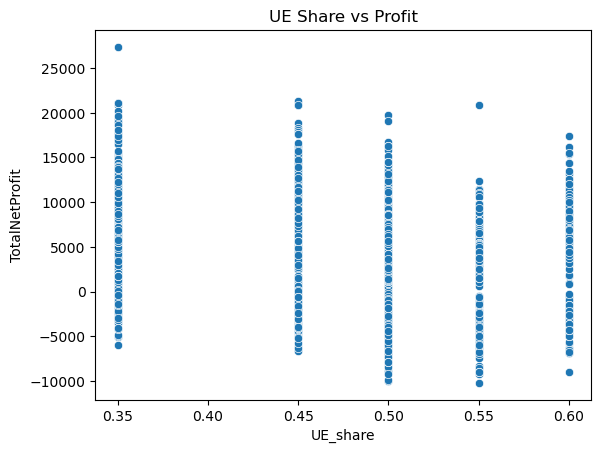

In [11]:
sns.scatterplot(x='UE_share', y='TotalNetProfit', data=df)
plt.title("UE Share vs Profit")
plt.show()

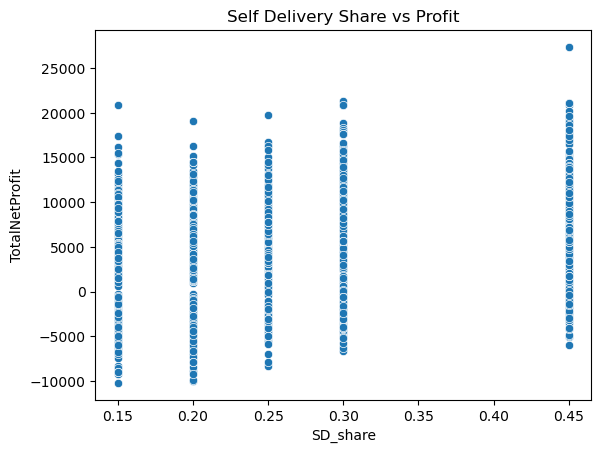

In [12]:
sns.scatterplot(x='SD_share', y='TotalNetProfit', data=df)
plt.title("Self Delivery Share vs Profit")
plt.show()


# Boxplots


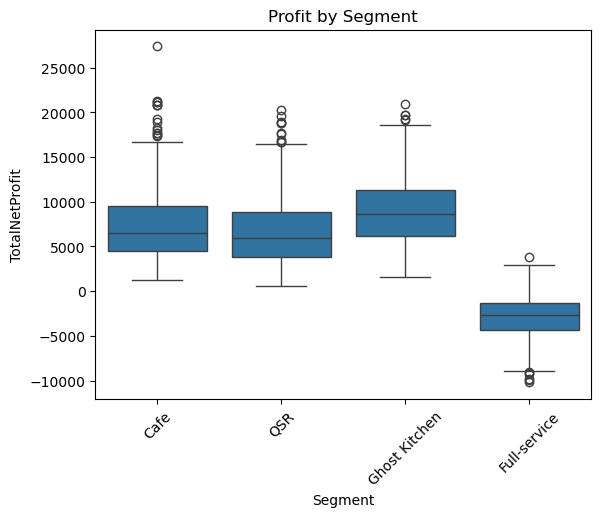

In [13]:
sns.boxplot(x='Segment', y='TotalNetProfit', data=df)
plt.xticks(rotation=45)
plt.title("Profit by Segment")
plt.show()